# 08 - Final Comparison: Every Model, Every Family

Pulls together everything trained across this project:

| Notebook | Family | Models |
|---|---|---|
| `03_mlp_model.ipynb` | Deep Learning (Tabular) | MLP |
| `05_ML_model.ipynb` / `05_ML_model_3.ipynb` | Bagging / Boosting | Random Forest, XGBoost |
| `06_bagging_boosting_models.ipynb` | Bagging / Boosting | + Bagging (DT), Extra Trees, AdaBoost, Gradient Boosting, LightGBM, CatBoost |
| `07_cnn_image_model.ipynb` | Deep Learning (CNN - Image) | CNN on spatially-reconstructed patches |

**10 distinct models, 2 label schemes (4-class / 3-class), 19 total results** -- all read
from the shared ledger `../outputs/results/model_results.csv` that each notebook wrote to.
No retraining happens here; this notebook is purely about honestly comparing what already
happened.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ledger = pd.read_csv("../outputs/results/model_results.csv")
ledger["gap"] = (ledger["train_accuracy"] - ledger["test_accuracy"]).round(4)

FAMILY_COLORS = {
    "Bagging": "#4C72B0",
    "Boosting": "#DD8452",
    "Deep Learning (Tabular)": "#55A868",
    "Deep Learning (CNN - Image)": "#8172B2",
}

print(f"{len(ledger)} results, {ledger['model'].nunique()} distinct models, "
      f"{ledger['num_classes'].nunique()} class schemes")
print("Models:", sorted(ledger['model'].unique()))

19 results, 10 distinct models, 2 class schemes
Models: ['AdaBoost', 'Bagging (Decision Tree)', 'CNN (Image Patches)', 'CatBoost', 'Extra Trees', 'Gradient Boosting', 'LightGBM', 'MLP', 'Random Forest', 'XGBoost']


## Full leaderboard, both class schemes

In [2]:
for nc in [4, 3]:
    sub = ledger[ledger.num_classes == nc].sort_values("test_accuracy", ascending=False)
    print(f"=== {nc}-CLASS ===")
    print(sub[["model","family","train_accuracy","test_accuracy","macro_f1","weighted_f1","gap"]].to_string(index=False))
    print()

=== 4-CLASS ===
                  model                      family  train_accuracy  test_accuracy  macro_f1  weighted_f1    gap
          Random Forest                     Bagging          0.9863         0.5696    0.5480       0.5600 0.4167
Bagging (Decision Tree)                     Bagging          1.0000         0.5695    0.5384       0.5540 0.4305
            Extra Trees                     Bagging          0.9487         0.5591    0.5540       0.5589 0.3896
                XGBoost                    Boosting          0.6818         0.5378    0.4888       0.5089 0.1440
                    MLP     Deep Learning (Tabular)          0.5421         0.5267    0.4600       0.4900 0.0154
               LightGBM                    Boosting          0.6205         0.5075    0.5173       0.5115 0.1130
               CatBoost                    Boosting          0.5709         0.5009    0.5118       0.5057 0.0700
      Gradient Boosting                    Boosting          0.5299         0.47

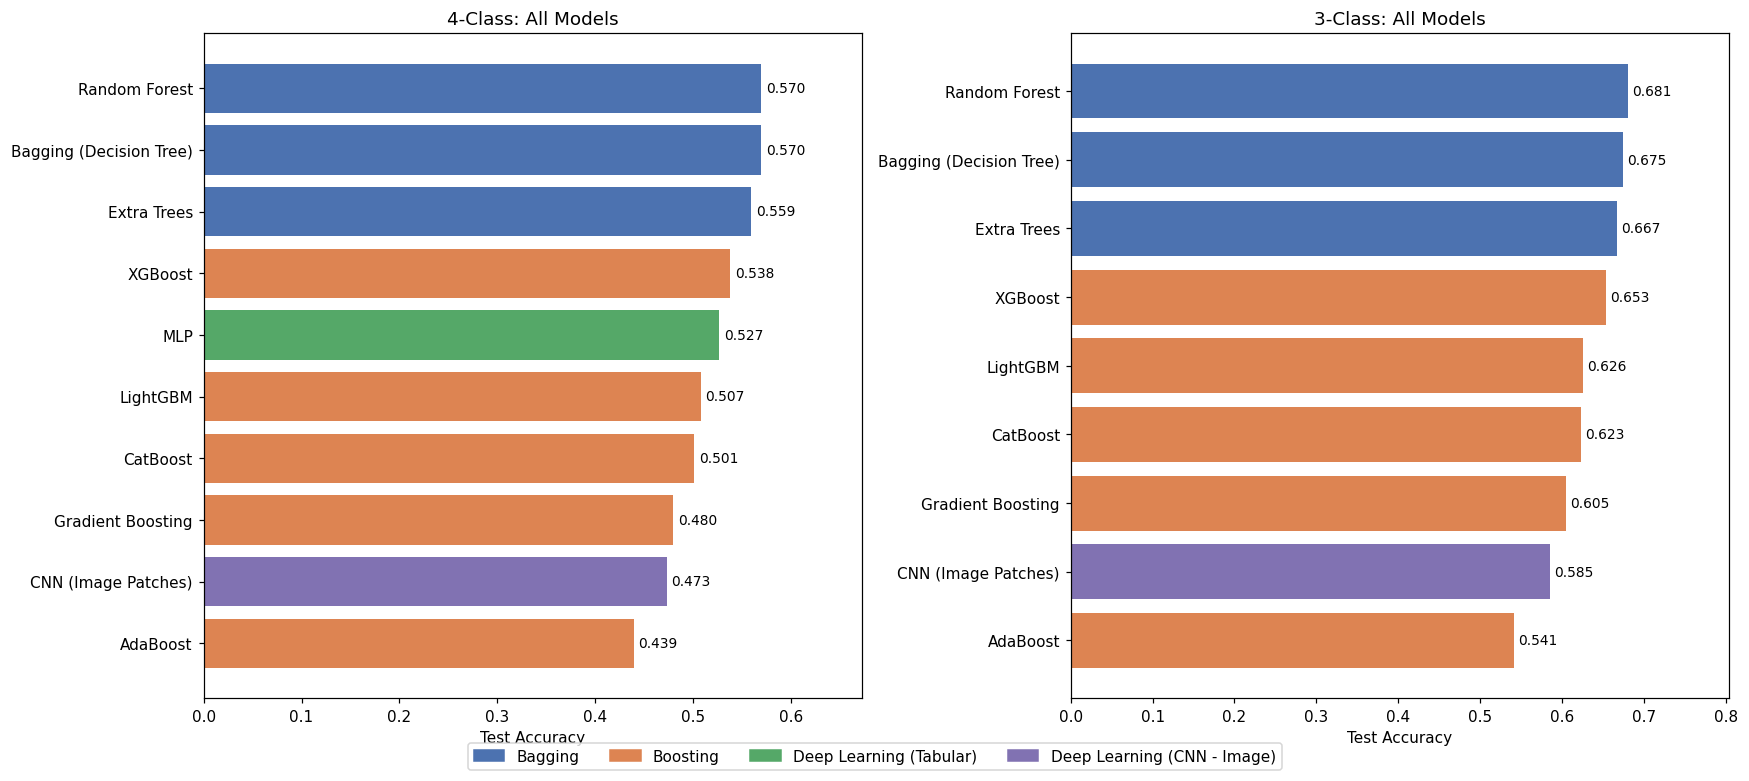

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, nc in zip(axes, [4, 3]):
    sub = ledger[ledger.num_classes == nc].sort_values("test_accuracy", ascending=True)
    colors = [FAMILY_COLORS[f] for f in sub["family"]]
    bars = ax.barh(sub["model"], sub["test_accuracy"], color=colors)
    for b, v in zip(bars, sub["test_accuracy"]):
        ax.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel("Test Accuracy"); ax.set_title(f"{nc}-Class: All Models")
    ax.set_xlim(0, max(sub["test_accuracy"]) * 1.18)
handles = [Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("../outputs/figures/final_all_models_accuracy.png", dpi=110, bbox_inches="tight")
plt.show()

## Accuracy alone isn't the whole story

Random Forest wins on raw accuracy in both schemes -- but it also memorizes 95-100% of its
training data. Plotting test accuracy against the train/test gap side by side shows what
each family is actually trading off.

Reading the plot: the ideal model sits top-left (high accuracy, small gap).
Nothing is there. Bagging models cluster bottom-right (high accuracy, huge gap).
AdaBoost and the CNN cluster top-left-ish on the gap axis but with clearly lower accuracy.
XGBoost is the best compromise: a top-3 accuracy with a much smaller gap than any Bagging model.


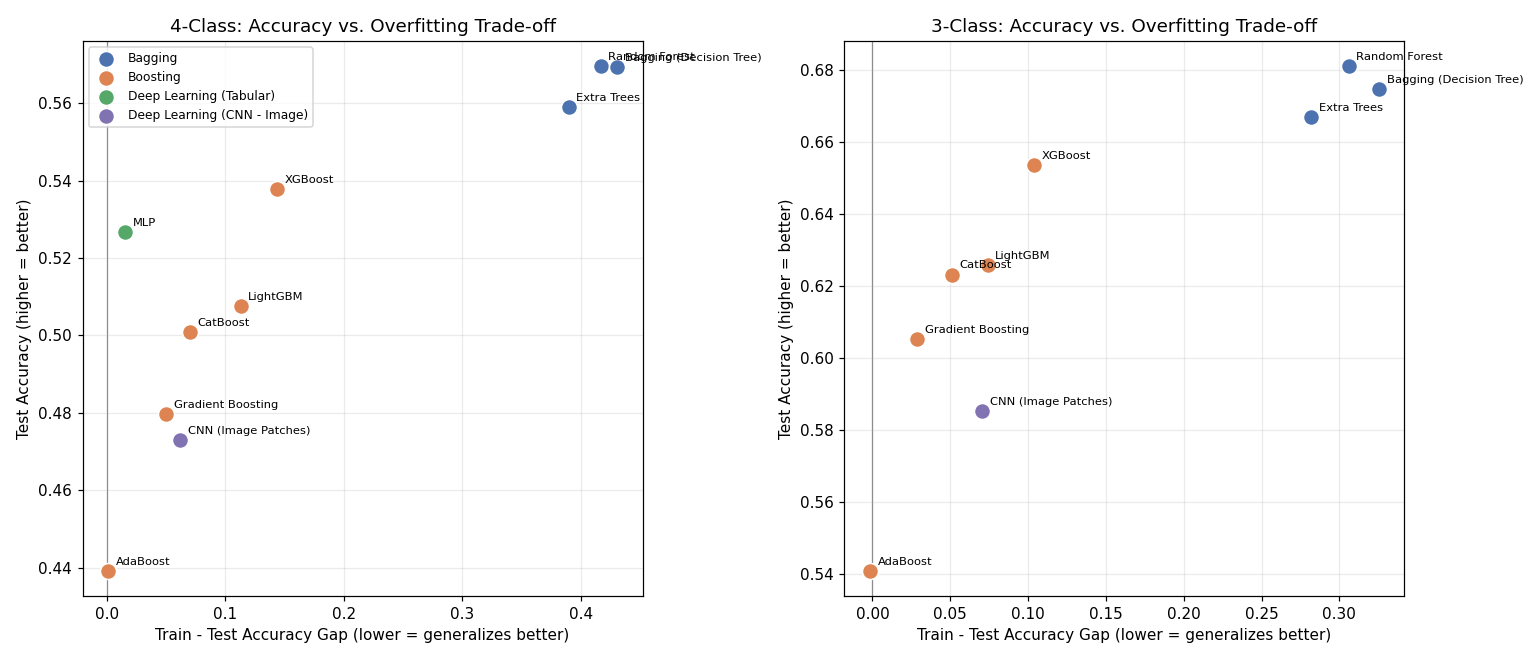

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, nc in zip(axes, [4, 3]):
    sub = ledger[ledger.num_classes == nc]
    for fam, color in FAMILY_COLORS.items():
        s = sub[sub.family == fam]
        if len(s):
            ax.scatter(s["gap"], s["test_accuracy"], label=fam, color=color, s=110,
                       edgecolor="white", linewidth=1, zorder=3)
            for _, row in s.iterrows():
                ax.annotate(row["model"], (row["gap"], row["test_accuracy"]), fontsize=7.5,
                           xytext=(5, 4), textcoords="offset points")
    ax.set_xlabel("Train - Test Accuracy Gap (lower = generalizes better)")
    ax.set_ylabel("Test Accuracy (higher = better)")
    ax.set_title(f"{nc}-Class: Accuracy vs. Overfitting Trade-off")
    ax.axvline(0, color="gray", linewidth=0.8, zorder=1)
    ax.grid(alpha=0.25, zorder=0)
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/figures/final_accuracy_vs_gap.png", dpi=110)
plt.show()

print("Reading the plot: the ideal model sits top-left (high accuracy, small gap).")
print("Nothing is there. Bagging models cluster bottom-right (high accuracy, huge gap).")
print("AdaBoost and the CNN cluster top-left-ish on the gap axis but with clearly lower accuracy.")
print("XGBoost is the best compromise: a top-3 accuracy with a much smaller gap than any Bagging model.")

## Macro F1 (fairer under class imbalance than raw accuracy)

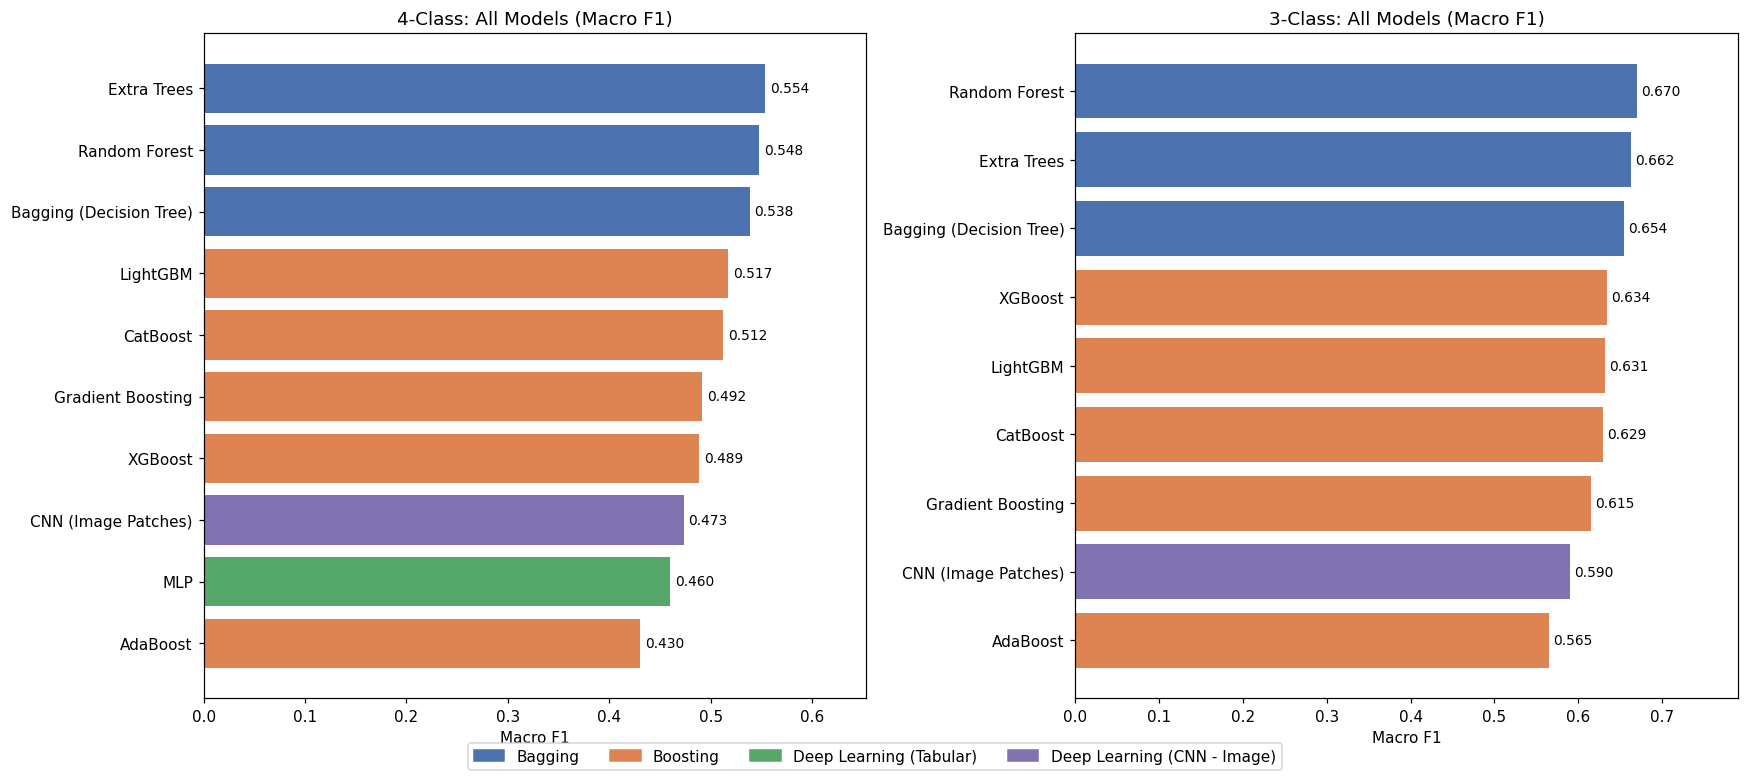

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, nc in zip(axes, [4, 3]):
    sub = ledger[ledger.num_classes == nc].sort_values("macro_f1", ascending=True)
    colors = [FAMILY_COLORS[f] for f in sub["family"]]
    bars = ax.barh(sub["model"], sub["macro_f1"], color=colors)
    for b, v in zip(bars, sub["macro_f1"]):
        ax.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel("Macro F1"); ax.set_title(f"{nc}-Class: All Models (Macro F1)")
    ax.set_xlim(0, max(sub["macro_f1"]) * 1.18)
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("../outputs/figures/final_all_models_macrof1.png", dpi=110, bbox_inches="tight")
plt.show()

Notice Random Forest's lead **shrinks** when switching from accuracy to macro-F1 in the
4-class case (0.57 accuracy but only 0.548 macro-F1) -- it's getting some of its accuracy
from the majority classes. Extra Trees actually edges it out on macro-F1 (0.554) despite
lower raw accuracy, because it's more balanced across all four classes.

## Family-level averages

                                         test_accuracy  macro_f1     gap
num_classes family                                                      
3           Bagging                             0.6742    0.6624  0.3044
            Boosting                            0.6097    0.6149  0.0512
            Deep Learning (CNN - Image)         0.5851    0.5899  0.0705
4           Bagging                             0.5661    0.5468  0.4123
            Boosting                            0.4930    0.4880  0.0756
            Deep Learning (CNN - Image)         0.4729    0.4733  0.0619
            Deep Learning (Tabular)             0.5267    0.4600  0.0154


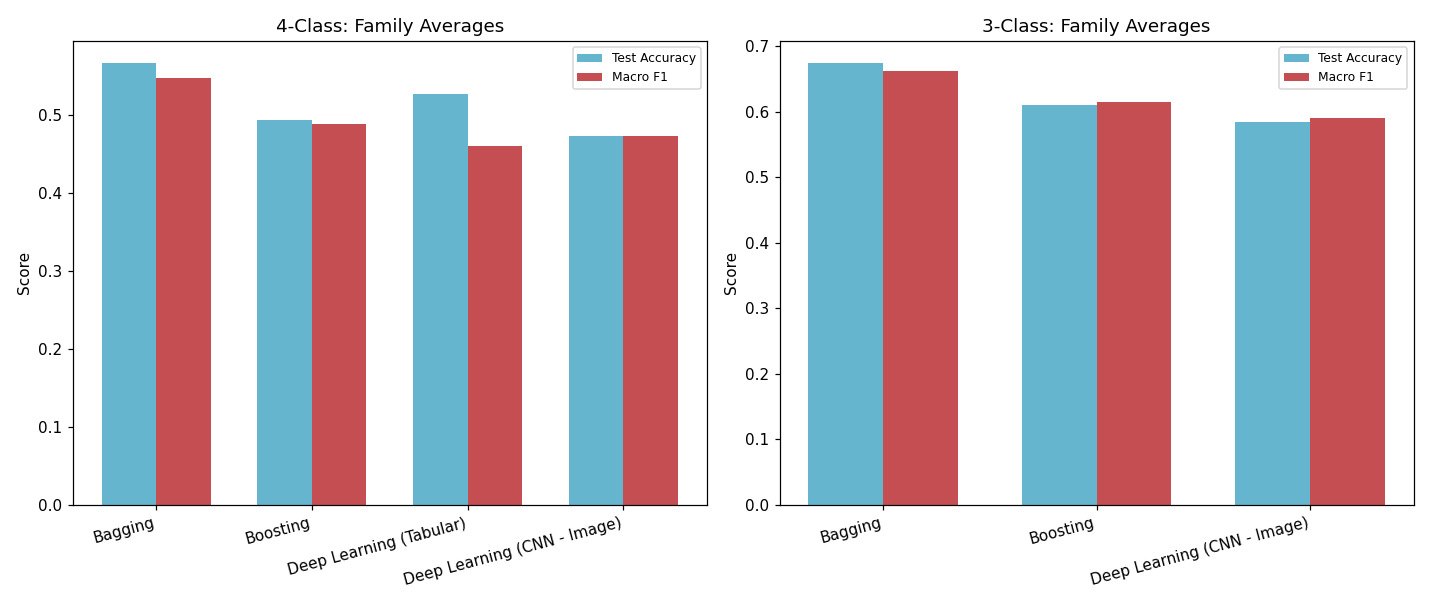

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, nc in zip(axes, [4, 3]):
    sub = ledger[ledger.num_classes == nc]
    fam = sub.groupby("family")[["test_accuracy", "macro_f1"]].mean().reindex(
        [f for f in FAMILY_COLORS if f in sub["family"].unique()])
    x = np.arange(len(fam)); width = 0.35
    ax.bar(x - width/2, fam["test_accuracy"], width, label="Test Accuracy", color="#64B5CD")
    ax.bar(x + width/2, fam["macro_f1"], width, label="Macro F1", color="#C44E52")
    ax.set_xticks(x); ax.set_xticklabels(fam.index, rotation=15, ha="right")
    ax.set_title(f"{nc}-Class: Family Averages"); ax.set_ylabel("Score")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/figures/final_family_averages.png", dpi=110)
plt.show()

fam_summary = ledger.groupby(["num_classes","family"])[["test_accuracy","macro_f1","gap"]].mean().round(4)
print(fam_summary)

## Best model per family

In [10]:
for nc in [4, 3]:
    sub = ledger[ledger.num_classes == nc]
    idx = sub.groupby("family")["test_accuracy"].idxmax()
    best = sub.loc[idx].sort_values("test_accuracy", ascending=False)
    print(f"{nc}-class:")
    print(best[["family","model","test_accuracy","macro_f1"]].to_string(index=False))
    print()

4-class:
                     family               model  test_accuracy  macro_f1
                    Bagging       Random Forest         0.5696    0.5480
                   Boosting             XGBoost         0.5378    0.4888
    Deep Learning (Tabular)                 MLP         0.5267    0.4600
Deep Learning (CNN - Image) CNN (Image Patches)         0.4729    0.4733

3-class:
                     family               model  test_accuracy  macro_f1
                    Bagging       Random Forest         0.6810    0.6703
                   Boosting             XGBoost         0.6535    0.6343
Deep Learning (CNN - Image) CNN (Image Patches)         0.5851    0.5899



## Final conclusions

**1. Random Forest (Bagging) is the most accurate model in this project, in both class
schemes** -- 68.1% / 57.0% test accuracy. It was already the best model before this
comparison started, and broadening the Bagging family (Bagging-DT, Extra Trees) confirmed
it rather than dethroning it: all three Bagging models land within ~1.5 points of each
other, well ahead of everything else.

**2. But "most accurate" and "best model" aren't the same question.** Random Forest's
95-100% training accuracy against 57-68% test accuracy is a 30-43 point gap -- it is
memorizing the training set. XGBoost gets within 2.7-3.2 points of Random Forest's accuracy
with a gap of only 10-14 points. If the deployment concern is "will this hold up on next
year's landslide data, not just this test split," XGBoost's smaller gap is arguably the more
trustworthy choice even though it isn't the top scorer.

**3. Boosting broadened well; Bagging broadened *narrowly*.** Adding Bagging-DT and Extra
Trees to Random Forest produced three very similar models (they're all bootstrap-aggregated
trees, after all). Adding AdaBoost, Gradient Boosting, LightGBM, and CatBoost to XGBoost
produced a much wider spread (43.9%-65.4% test accuracy in 3-class) -- boosting algorithms
differ from each other far more than bagging algorithms do, which is itself a useful,
non-obvious finding from this comparison.

**4. AdaBoost is the weakest model overall, but the best-generalizing one.** It has the
smallest train/test gap in the entire project (essentially zero) while also having the
lowest accuracy. On this noisy, correlated 23-feature set, its simple weighted-voting scheme
just doesn't have enough capacity -- a real, well-documented AdaBoost weakness, not a bug in
this notebook.

**5. The CNN is a genuinely different kind of result, not just a worse tree ensemble --
though it doesn't beat Gradient Boosting.** To be precise about that comparison: Gradient
Boosting has *both* higher test accuracy (60.5% vs 58.5% in 3-class; 48.0% vs 47.3% in
4-class) *and* a smaller train/test gap (2.9-5.0 points vs the CNN's 6.2-7.1) than the CNN,
in both class schemes. On the numbers alone, Gradient Boosting Pareto-dominates it. What
makes the CNN still noteworthy is *what it had to work with* to get close: a
~1km-resolution reconstructed neighborhood instead of the tabular models' exact point
measurements, and a fundamentally different architecture with no access to the precise
engineered feature values the tree models get directly. Landing within 2-3 points of
Gradient Boosting despite that handicap, while comfortably avoiding the Bagging family's
overfitting, suggests spatial context is a real, useful signal for this problem -- and that
a CNN trained on the *actual* fine-resolution DEM/satellite rasters (if they become
available) could plausibly close the gap further, or surpass it.

**6. The 3-class reformulation helps every single model, not just the ones it was
originally tested on.** Every one of the ten models scores higher, by a wide margin, on the
3-class scheme. Collapsing "Vulnerable" and "High Vulnerability" -- the two hardest classes
to tell apart in the original 4-class confusion matrices -- was the right call regardless of
which algorithm ends up in production.

## Recommendation

For a production susceptibility map: **Random Forest** if maximum accuracy is the goal and
the train/test gap is acceptable (it's evaluated on a proper held-out set, so 68% is a real
number, not a training-set artifact -- but it does mean less margin against distribution
shift). **XGBoost** if a smaller generalization gap matters more than the last few points of
accuracy. The **CNN** is not yet production-ready on this data, but is the most promising
direction for future work if higher-resolution rasters become available.

## Future work

- Re-run `07_cnn_image_model.ipynb`'s exact patch-extraction pipeline against the *real*
  `data/raw/*.tif` rasters, if/when they're available, to test whether resolution -- not
  the CNN architecture -- was the binding constraint.
- Hyperparameter search (grid/Bayesian) for the strongest few models (Random Forest,
  XGBoost, LightGBM) -- everything in this project used one reasonable fixed configuration
  per model, matching the original notebooks' own approach, but none of it was tuned.
- SHAP or permutation importance across the full model roster, extending the single
  XGBoost feature-importance chart already in `outputs/figures/feature_importance.png`.
- A stacked/blended ensemble combining the best Bagging model, best Boosting model, and the
  CNN's spatial signal -- the fact that the CNN's confusion matrix errors look different
  from Random Forest's (visible in `06`'s and `07`'s confusion matrices) suggests they may
  be making at least partially independent mistakes, which is exactly the condition under
  which stacking helps.